In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib
import sys
sys.path.append("../src")

from logger import Logger
import numpy as np


/mnt/home/rwiersema/blurred_sampling/.venv_plot/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: On GPUs an efficient choice is to run ~512 Markov Chains per GPU.

In [8]:
import jax.numpy as jnp
import numpy as np
import jax
from netket.operator.spin import sigmax, sigmaz
from metropolis import LocalDoubleFlipRule
import netket as nk
import qutip as qt

alpha = 4
q=0.5
driver_type="geometric"
# ansatz="TFIM_PFAFF_"
ansatz="TFIM_"
# h = 0.125
h = 1.0
J = 1.0


def get_model(alpha):
    return nk.models.RBM(
        alpha=alpha,
        param_dtype=complex,
    )


def get_vstate(hilbert):
    seed = 300
    n_samples = 2**10
    model = get_model(alpha)
    sampler = nk.sampler.MetropolisSampler(
        hilbert, LocalDoubleFlipRule(), n_chains=n_samples
    )
    vstate = nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=seed, sampler_seed=seed
    )

    # zero everything
    pars = jax.tree_util.tree_map(lambda x: jnp.zeros_like(x), vstate.parameters)

    W = pars["Dense"]["kernel"]
    b = pars["Dense"]["bias"]
    n = hilbert.size
    # b + W x = i pi/4 (1 - sum_i x_i), x_i in \{+1,-1\}
    #   -> even x: b + W x = i(k+1) pi /2 ->  cosh(b + W x)= +-1
    #   -> odd x: b + W x = i k pi /2 -> cosh(b + W x)= 0
    W = W.at[:, 0].set(-1j * (np.pi / 4))
    b = b.at[0].set(1j * (np.pi / 4) * n)
    # Repeat to get rid of sign since now
    # psi(x) =  cosh(b_0 + sum_i W_0i x) * cosh(b_1 + sum_i W_1i x)
    #   -> even x: 1
    #   -> odd x: 0
    W = W.at[:, 1].set(-1j * (np.pi / 4))
    b = b.at[1].set(1j * (np.pi / 4) * n)
    # Unit 3 left as zero (neutral)
    pars["Dense"]["kernel"] = W
    pars["Dense"]["bias"] = (
        b + jax.random.uniform(jax.random.key(100), b.shape) * 1e-3 * n
    )
    pars["visible_bias"] = jnp.zeros_like(pars["visible_bias"])

    # visible_bias stays zero
    vstate.parameters = pars
    return vstate


def get_exact(N, h, J, T):
    print("Load exact data from {ansatz}exact.ipynb")
    save_path = f"./data/TFIM_exact_parity/"
    try:
        times_exact = np.load(save_path + f"times_{N}_h{h:1.3f}_J{J:1.2f}_T{T:1.2f}.npy")
        parity_exact = np.load(save_path + f"parityZ_{N}_h{h:1.3f}_J{J:1.2f}_T{T:1.2f}.npy")
    except FileNotFoundError:
        file = save_path + f"times_{N}_h{h:1.2f}_J{J:1.2f}.npy"
        raise FileNotFoundError(
            f"File {file} does not exist, produce it first with {ansatz}exact.ipynb"
        )


    # # Plot the exact dynamics
    # plt.figure(figsize=(8, 5))
    # plt.plot(
    #     times_exact, np.real(parity_exact), "k-", linewidth=2, label="Exact (QuTiP)"
    # )
    # plt.xlabel("Time t")
    # plt.ylabel(r"$\langle \prod_i \sigma^z_i \rangle$")
    # plt.title("Exact Quantum Dynamics of Parity")
    # plt.ylim([-1.05, 1.05])
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    # plt.show()

    print(f"Initial parity: {np.real(parity_exact[0]):.6f}")
    print(f"Final parity: {np.real(parity_exact[-1]):.6f}")
    return times_exact, parity_exact

In [9]:

def plot(save_path):
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())

    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    (ax_snr, ax_snrF, ax_dt) = axs[0]
    (ax_z, ax_ess, ax_rsq) = axs[1]
    print(logger.data["parity"]["Mean"])
    ax_z.plot(logger.data["t"]["values"], logger.data["parity"]["Mean"], "*-")
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"Parity")

    t, val = get_exact(N, h, J, T)
    ax_z.plot(t, val, linestyle="--", color="red", label="Exact")
    # ax_z.set_xlim(0,0.2)

    x_vals = logger.data["t"]["values"]
    ess_vals = logger.data["ess_bridge"]["values"]
    q_vals = logger.data["q_bridge"]["values"]
    print(q_vals)
    if ess_vals and q_vals:
        ax_right = ax_ess.twinx()
        (line1,) = ax_ess.plot(x_vals, ess_vals, color="tab:blue", label="ESS (bridge)")
        # Also plot max_weight_over_mean on left axis
        (line2,) = ax_right.plot(x_vals, q_vals, color="tab:orange", label="q (bridge)")
        target_ess = 0.1
        ax_right.axhline(
            target_ess,
            color="tab:blue",
            linestyle="--",
            linewidth=1,
            alpha=0.7,
            label=f"ess target = {target_ess:1.2f}",
        )

        ax_ess.set_xlabel("Step")
        ax_ess.set_ylabel("ESS (bridge)", color="tab:blue")
        ax_right.set_ylabel("q (bridge)", color="tab:orange")
        ax_ess.set_ylim(-0.05, 1.05)
        ax_right.set_ylim(0.0, 1.05)
        ax_ess.grid(True, alpha=0.3)
        ax_ess.set_title("Bridge ESS, q")

        lines = [line1, line2]
        labels = [l.get_label() for l in lines]
        # Include max_weight_over_mean if present
        ax_ess.legend(
            lines + [ax_right.lines[-1]],
            labels + [f"ess target = {target_ess:1.2f}"],
            loc="best",
        )

    # Top-left: SNR (eigenbasis) sorted curves with log y; add median and min lines
    snr_len = len(logger.data.get("snr", {}).get("values", []))
    cmap_snr = plt.get_cmap("viridis")
    # Normalize step index to [0,1] for colorbar
    norm_frac = colors.Normalize(vmin=0.0, vmax=1.)
    for i in range(snr_len):
        snr_data = np.array(logger.data["snr"]["values"][i]).flatten()
        frac = 0.0 if snr_len <= 1 else i / 40
        ax_snr.plot(np.sort(snr_data), color=cmap_snr(norm_frac(frac)))
    # Summary lines from monitor
    snr_med_series = logger.data.get("snr_med", {}).get("values", [])
    snr_min_series = logger.data.get("snr_min", {}).get("values", [])
    if len(snr_med_series) > 0:
        ax_snr.axhline(
            np.array(snr_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    ax_snr.set_xlabel(r"Mode index $k$")
    ax_snr.set_ylabel("SNR (eigenbasis)")
    ax_snr.set_title(rf"SNR($\rho_k$) over time")
    ax_snr.set_yscale("log")
    # ax_snr.set_ylim([1e-6, 1e7])
    ax_snr.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    cmap_snr = plt.get_cmap('viridis')
    norm_frac = colors.Normalize(vmin=0.0, vmax=1.0)
    sm_snr = plt.cm.ScalarMappable(cmap=cmap_snr, norm=norm_frac)
    sm_snr.set_array([])
    fig.colorbar(sm_snr, ax=ax_snr, pad=0.02, label="t")

    # Top-middle: SNR(F) sorted curves with log y; add median and min lines
    snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
    cmap_snrF = plt.get_cmap("Blues")
    for i in range(snrF_len):
        snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
        frac = 0.0 if snrF_len <= 1 else i / (snrF_len - 1)
        ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
    snrF_med_series = logger.data.get("snrF_med", {}).get("values", [])
    snrF_min_series = logger.data.get("snrF_min", {}).get("values", [])
    if len(snrF_med_series) > 0:
        ax_snrF.axhline(
            np.array(snrF_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    # if len(snrF_min_series) > 0:
    #     ax_snrF.axhline(np.array(snrF_min_series)[-1], color="gray", linestyle=":", label="min")
    ax_snrF.set_xlabel(r"Parameter index $k$")
    ax_snrF.set_ylabel("SNR(F)")
    ax_snrF.set_title(rf"SNR(F) over time")
    ax_snrF.set_yscale("log")
    # ax_snrF.set_ylim([1e-2, 1e2])
    ax_snrF.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    cmap_snrF = plt.get_cmap("viridis")
    sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
    sm_snrF.set_array([])
    if logger.data["dt"]["values"]:
        ax_dt.plot(x_vals, logger.data["dt"]["values"])
        ax_dt.set_xlabel("Step")
        ax_dt.set_ylabel("dt")
        ax_dt.set_title("Adaptive time step")
        ax_dt.set_yscale("log")
        ax_dt.set_ylim([1e-5, 5e-2])

    
    # Add cumulative r_squared on right axis
    r_sq = logger.data["r_squared"]["values"]
    if r_sq:
        t_vals = logger.data["t"]["values"]
        ax_rsq.plot(t_vals, r_sq, color="tab:purple")
        ax_rsq.set_xlabel("t")
        ax_rsq.set_ylabel("r_squared", color="tab:purple")
        ax_rsq.set_title("Generator r_squared vs time")
        r_sq_arr = np.array(r_sq, dtype=float)
        if np.any(np.isfinite(r_sq_arr) & (r_sq_arr > 0.0)):
            ax_rsq.set_yscale("log")

        ax_rsq_right = ax_rsq.twinx()
        r_sq_arr = np.array(r_sq, dtype=float)
        r_sq_cum = np.nancumsum(r_sq_arr)
        ax_rsq_right.plot(
            t_vals, r_sq_cum, color="tab:green", label="cumulative r_squared"
        )
        ax_rsq_right.set_ylabel("cumulative r_squared", color="tab:green")
        ax_rsq_right.tick_params(axis="y")
        ax_rsq_right.set_yscale("log")

    plt.tight_layout()
    plt.savefig(save_path+"stats.pdf")
    plt.show()


fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("r_squared", "values"),
    ("parity", "Mean"),
    ("parity", "Variance"),
    # SNR monitoring fields
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("snr", "values"),
    ("snr_F", "values"),
    # Bridge
    ("ess_bridge", "values"),
    ("q_bridge", "values"),
)

File not found
Restored: False
[]


/tmp/ipykernel_3428751/3197557073.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_z.legend()


NameError: name 'T' is not defined

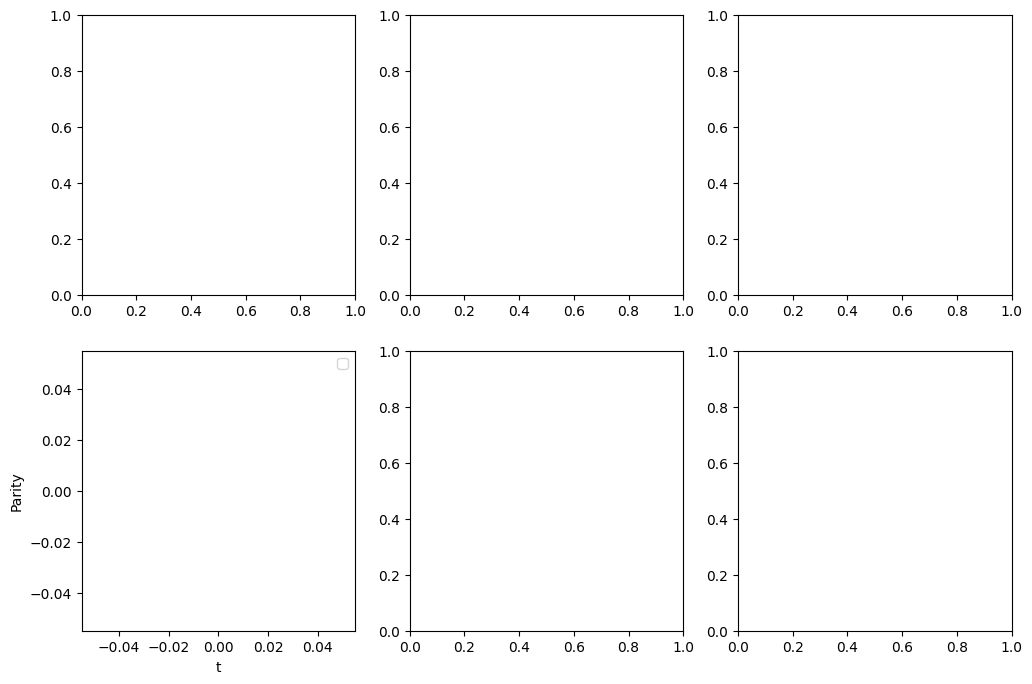

In [5]:
n_samples_tvmc = 2**10
N = 8
if driver_type in ["bridge", "geometric"]:   
    exp_name = f"{driver_type}_{n_samples_tvmc}_{q:1.2f}/"
else:
    exp_name = f"{driver_type}_{n_samples_tvmc}/"
if ansatz=="TFIM_":
    save_path = f"./data/{ansatz}{N}_{alpha}_parity/{exp_name}"
else:
    save_path = f"./data/{ansatz}{N}_parity/{exp_name}"
plot(save_path) 

Restored: True
[array(0.99829102+3.59543643e-17j), array(0.99438477-1.76733409e-16j), array(0.98388672+7.97797572e-17j), array(0.97094727-1.05501085e-16j), array(0.94824219-1.20510058e-16j), array(0.92211914-2.60413793e-16j), array(0.88378906+3.05757106e-17j), array(0.84594727+9.30566718e-17j), array(0.79223633+6.04998659e-17j), array(0.74462891-5.27727624e-17j), array(0.69482422-1.70431069e-16j), array(0.63842773+1.29128813e-16j), array(0.5690918-5.73988469e-17j), array(0.49829102-1.74520088e-17j), array(0.4296875-1.76211516e-16j), array(0.37182617-5.77525009e-17j), array(0.28588867-6.58384732e-17j), array(0.22216797+1.42876417e-17j), array(0.15356445+8.58399914e-17j), array(0.07836914-1.33800513e-16j), array(-0.01855469+1.18482232e-17j), array(-0.09472656-1.01650997e-17j), array(-0.16113281-7.23503912e-17j), array(-0.23510742+9.17336682e-19j), array(-0.3190918+1.10513547e-16j), array(-0.36938477-1.78853552e-16j), array(-0.44677734+7.01327001e-17j), array(-0.5090332-1.72916286e-16j), 

/tmp/ipykernel_3428751/3197557073.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_z.legend()


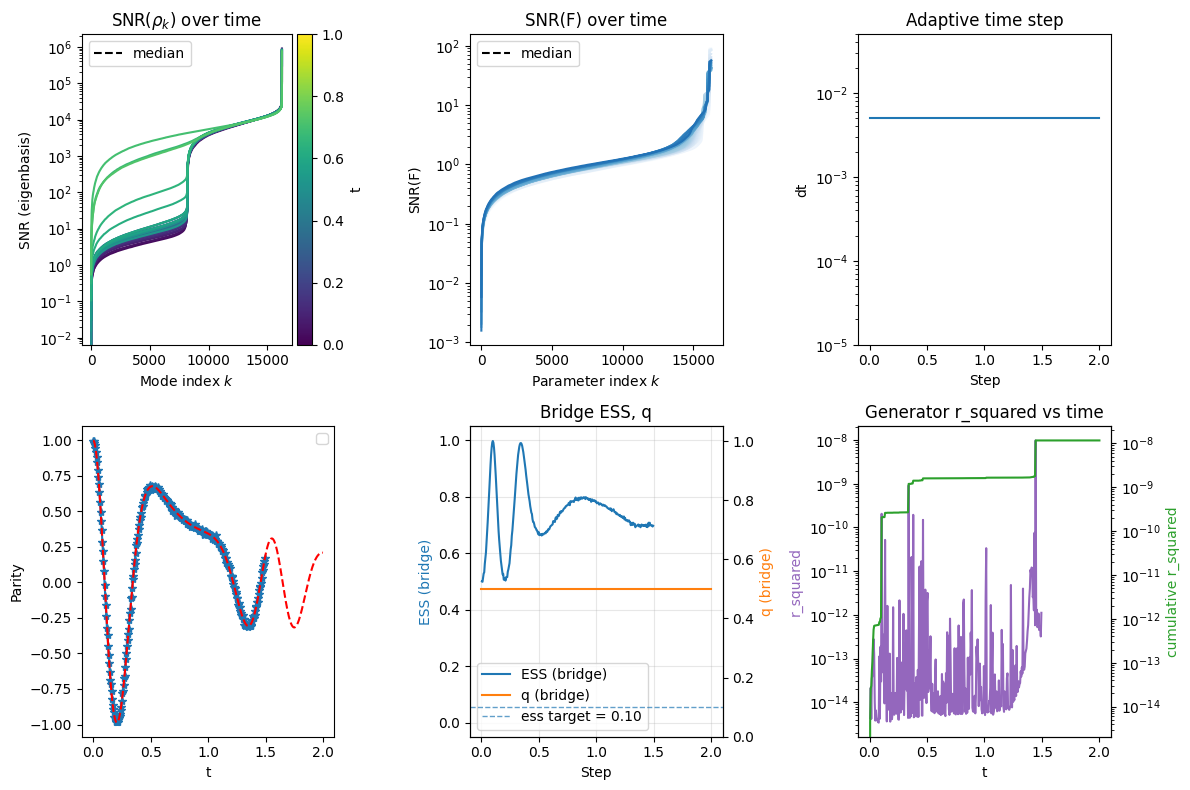

In [10]:
N = 64
h = 1/8
J = 1
T = 2
Ns = 2**13
from tfim_exact_majorana import run_ed
run_ed(N, h=h, J=J, T=T)
plot(f"./data/res_parity_pfaffian/bridge_{Ns}_h_{h:1.3f}_q_{q:1.3f}_T_{T:1.3f}/") 

# Paper plot

Load exact data from {ansatz}exact.ipynb
Initial parity: 1.000000
Final parity: -0.463829
File not found
Restored: False
File not found
Restored q:0.10 False
File not found
Restored q:0.30 False
Restored q:0.50 True
File not found
Restored q:0.70 False
File not found
Restored q:0.90 False
File not found
Restored q:0.10 False
[]
File not found
Restored q:0.30 False
[]
File not found
Restored q:0.50 False
[]
File not found
File not found


/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_1541026/2892124331.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z.plot(
/tmp/ipykernel_1541026/2892124331.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.95, 1])


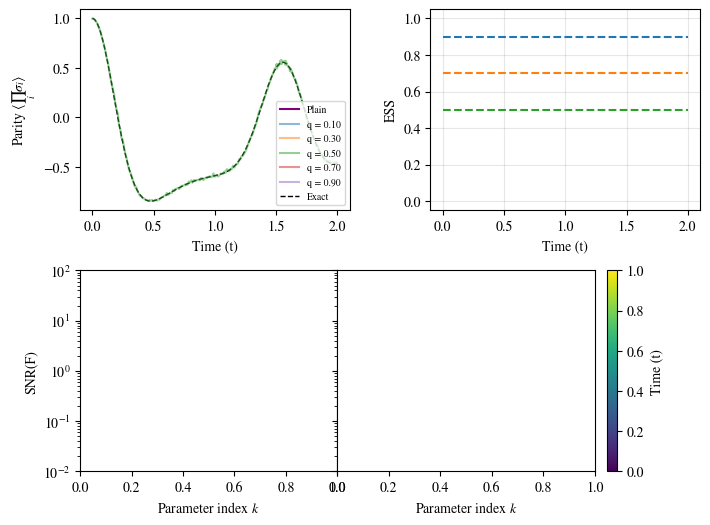

In [ ]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
n_samples_list = [2**i for i in range(10, 14)]
N = 4
times_exact, parity_exact = get_exact(N, h, J, T=2.0)

# Create figure with custom GridSpec for bottom row spacing
fig = plt.figure(figsize=(8, 6))
gs = fig.add_gridspec(
    2, 2, hspace=0.3, wspace=0.3, width_ratios=[1, 1], height_ratios=[1, 1]
)
# Top row with normal spacing
ax_z = fig.add_subplot(gs[0, 0])
ax_ess = fig.add_subplot(gs[0, 1])
# Bottom row with no horizontal spacing
gs_bottom = gs[1, :].subgridspec(1, 2, wspace=0)
ax_snrF_bridge = fig.add_subplot(gs_bottom[0])
ax_snrF_vanilla = fig.add_subplot(gs_bottom[1])

# Vanilla Parity
n_samples_vanilla = 2**10
save_path_vanilla = f"./data/{ansatz}{N}_{alpha}_parity/vanilla_{n_samples_vanilla}/"
logger_vanilla = Logger(path=save_path_vanilla, fields=fields_to_track)
print("Restored:", logger_vanilla.restore())
ax_z.plot(
    logger_vanilla.data["t"]["values"],
    logger_vanilla.data["parity"]["Mean"],
    label=f"Plain",
    zorder=1,
    color="purple",
)
ax_z.set_xlabel("Time (t)")
ax_z.set_ylabel(r"Parity $\langle\prod_i \sigma_i\rangle$")
n_samples_to_plot = 2**13
# Bridge Parity
for q in (0.1, 0.3, 0.5, 0.7, 0.9):
    for n_samples in [n_samples_to_plot]:
        exp_name = f"bridge_{n_samples}_{q:1.2f}"
        save_path = f"./data/{ansatz}{N}_{alpha}_parity/{exp_name}/"
        logger = Logger(path=save_path, fields=fields_to_track)
        print(f"Restored q:{q:1.2f}", logger.restore())
        ax_z.plot(
            logger.data["t"]["values"],
            logger.data["parity"]["Mean"],
            label=f"q = {q:1.2f}",
            zorder=0,
            alpha=0.5,
        )
ax_z.plot(
    times_exact, np.real(parity_exact), "k-", linewidth=1, label="Exact", zorder=-1, linestyle='dashed'
)
ax_z.legend(loc="lower right", fontsize=7)

# ESS
for q in (0.1, 0.3, 0.5, 0.7, 0.9)[:3]:
    for n_samples in [n_samples_to_plot]:
        exp_name = f"bridge_{n_samples}_{q:1.2f}"
        save_path = f"./data/{ansatz}{N}_{alpha}_parity/{exp_name}/"
        logger = Logger(path=save_path, fields=fields_to_track)
        print(f"Restored q:{q:1.2f}", logger.restore())
        x_vals = logger.data["t"]["values"]
        ess_vals = logger.data["ess_bridge"]["values"]
        print(ess_vals)
        (line1,) = ax_ess.plot(x_vals, ess_vals, label=f"q = {q:1.2f}")
        # Add marker at (0, q)
        ax_ess.hlines(1 - q, 0, 2.0, color=line1.get_color(), linestyle="dashed")

ax_ess.set_xlabel("Time (t)")
ax_ess.set_ylabel("ESS")
ax_ess.set_ylim(-0.05, 1.05)
ax_ess.grid(True, alpha=0.3)
# SNR F
norm_frac = colors.Normalize(vmin=0.0, vmax=1.0)
for i, sp in enumerate([save_path, save_path_vanilla]):
    if i == 0:
        ax = ax_snrF_bridge
    else:
        ax = ax_snrF_vanilla
    logger = Logger(path=sp, fields=fields_to_track)
    logger.restore()
    # Include max_weight_over_mean if present
    snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
    cmap_snrF = plt.get_cmap("viridis")
    for i in range(snrF_len):
        snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
        # print(snr_F_data)
        frac = 0.0 if snrF_len <= 1 else i / 40
        ax.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
    snrF_med_series = logger.data.get("snrF_med", {}).get("values", [])
    snrF_min_series = logger.data.get("snrF_min", {}).get("values", [])
    ax.set_xlabel(r"Parameter index $k$")

    ax.set_yscale("log")
ax_snrF_bridge.set_ylabel("SNR(F)")
# Share y-axis between bridge and vanilla plots
ax_snrF_vanilla.sharey(ax_snrF_bridge)
# Hide inner y-axis labels
ax_snrF_vanilla.tick_params(labelleft=False)
ax_snrF_bridge.tick_params(labelright=False)
ax_snrF_bridge.set_ylim([1e-2, 1e2])
# Show outer y-axis labels

# Add colorbar for ax_snrF_vanilla
sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
sm_snrF.set_array([])
cbar = fig.colorbar(
    sm_snrF, ax=[ax_snrF_bridge, ax_snrF_vanilla], pad=0.02, label="Time (t)", aspect=20
)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.savefig("./figures/Fig3.pdf")
plt.show()